In [2]:
from mtri_gmsh_helpers import *
import numpy as np
import netCDF4 as nc

In [3]:
mesh = load_triangulation('unique_triangulation.pkl')

Triangulation loaded from unique_triangulation.pkl


In [4]:
new_geometry_fname = "/users/hasanm4/lore.scorec.rpi.edu/wsources/DEGAS2-XGC/simulationRuns/test-mesh-verification/new-results/geometry.nc"
orig_geometry_fname = "/users/hasanm4/lore.scorec.rpi.edu/wsources/DEGAS2-XGC/simulationRuns/test-mesh-verification/orig-results/geometry.nc"

In [5]:
out_r=np.array([1.5       , 2.        , 2.5       , 1.08333333, 2.91666667,
       1.45      , 2.03333333, 2.61666667, 1.61666667, 2.45      ,
       1.25      , 2.75      ])
out_z=np.array([-0.91666667, -0.75      , -0.91666667, -0.5       , -0.5       ,
       -0.08333333, -0.25      , -0.08333333,  0.5       ,  0.5       ,
        0.75      ,  0.75      ])

new_density = np.array([9.13119420e+13, 6.86170549e+12, 5.59118112e+13, 1.30432350e+14,
       4.86733575e+13, 5.70129683e+12, 1.06050347e+12, 3.44841546e+12,
       7.29095458e+12, 5.31592041e+12, 1.38438004e+14, 6.72286170e+13])

orig_density = np.array([3.44089761e+13, 3.06385130e+12, 2.31844619e+13, 5.09207204e+13,
       2.04310480e+13, 2.76489530e+12, 4.26037669e+11, 1.60132475e+12,
       3.72863284e+12, 2.34240835e+12, 5.98267254e+13, 2.52350627e+13])

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Number of cells = 40


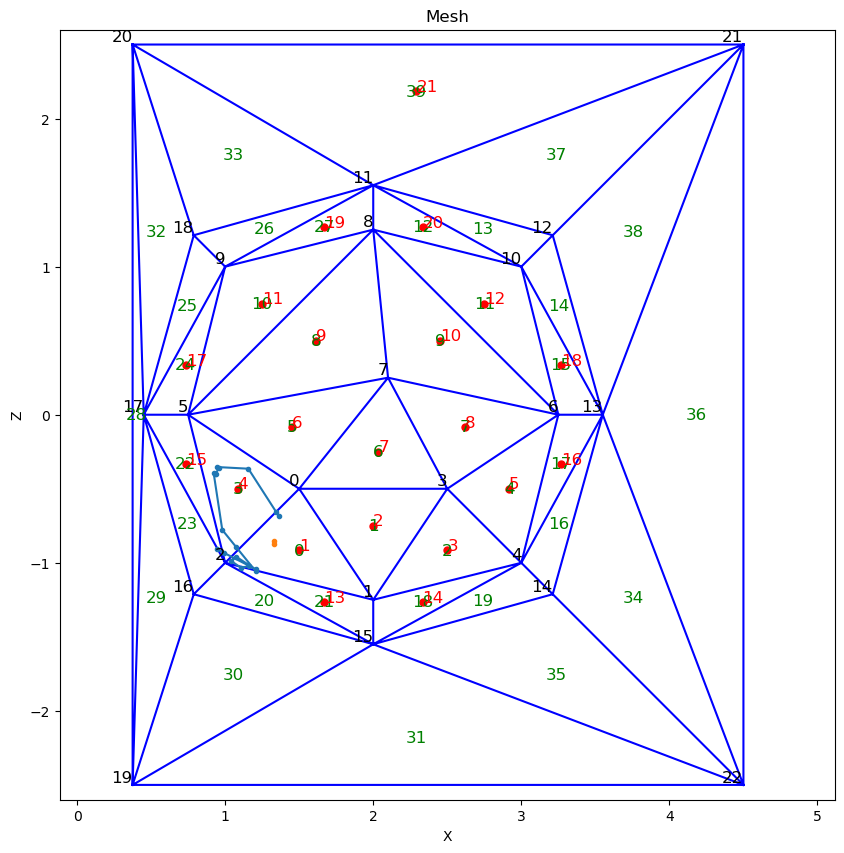

In [10]:
ds = nc.Dataset(new_geometry_fname, 'r')
print(f"Number of cells = {ds.variables['ncells'][:]}")

zone_centers = ds.variables['zone_center'][:]
zone_centers = np.array(zone_centers)
zone_volumes = ds.variables['zone_volume'][:]
zone_volumes = np.array(zone_volumes)
ds.close()

fig, ax = plt.subplots()
#plot_values_on_triangles(mesh, new_density, axis=ax, cmap='viridis')

plot_triangulation_with_labels(mesh, axis=ax)

# print zone ids
for i, (x, z) in enumerate(zone_centers[:, [0, 2]]):
    ax.text(x, z, str(i+1), color='red', fontsize=12)
    
# plot dot at zone centers
ax.plot(zone_centers[:, 0], zone_centers[:, 2], 'ro', markersize=5)

# plot r-z points
#ax.plot(out_r, out_z, 'bx', markersize=10, label='r-z points')
# they are just zone centroids
# plot desnity values for triangles of mesh

flights_file = "/users/hasanm4/lore.scorec.rpi.edu/wsources/DEGAS2-XGC/simulationRuns/test-mesh-verification/orig-results/flights1"
plot_flight_path_from_flights_file(flights_file, axis=ax)

ax.set_xlabel('X')
ax.set_ylabel('Z')
# equal axis scaling
ax.set_aspect('equal')
ax.set_xlim(0,5)
ax.set_ylim(-2.6,  2.6)
fig.set_size_inches(10, 10)
plt.show()

Number of cells = 46


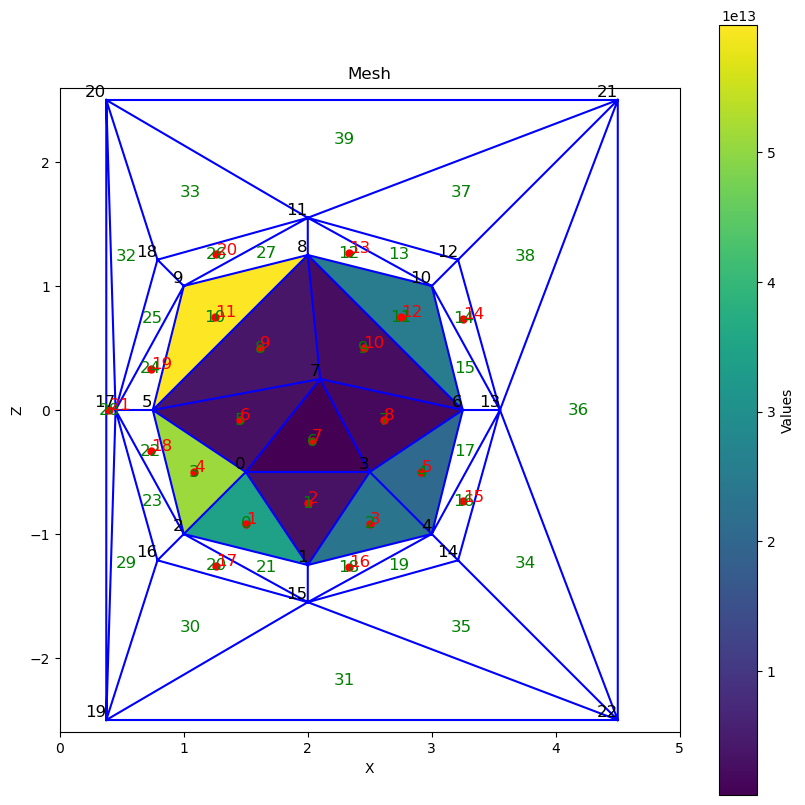

In [7]:
ds = nc.Dataset(orig_geometry_fname, 'r')
print(f"Number of cells = {ds.variables['ncells'][:]}")

zone_centers = ds.variables['zone_center'][:]
zone_centers = np.array(zone_centers)
zone_volumes = ds.variables['zone_volume'][:]
zone_volumes = np.array(zone_volumes)
ds.close()

fig, ax = plt.subplots()
plot_values_on_triangles(mesh, orig_density, axis=ax, cmap='viridis')

plot_triangulation_with_labels(mesh, axis=ax)

# print zone ids
for i, (x, z) in enumerate(zone_centers[:, [0, 2]]):
    ax.text(x, z, str(i+1), color='red', fontsize=12)
    
# plot dot at zone centers
ax.plot(zone_centers[:, 0], zone_centers[:, 2], 'ro', markersize=5)

ax.set_xlabel('X')
ax.set_ylabel('Z')
# equal axis scaling
ax.set_aspect('equal')
ax.set_xlim(0,5)
ax.set_ylim(-2.6,  2.6)
fig.set_size_inches(10, 10)
plt.show()

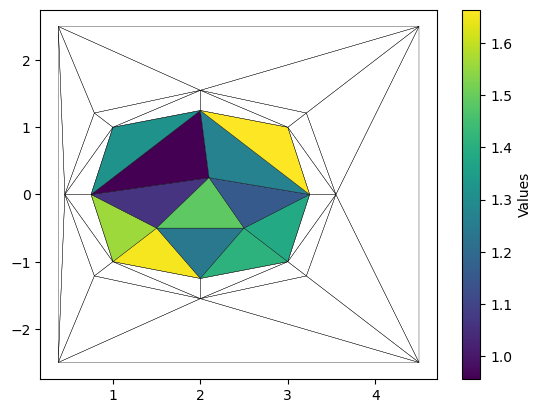

In [8]:
diff_density = np.abs(new_density - orig_density)
rel_diff_density = diff_density / np.abs(orig_density)

fig, ax = plt.subplots()
plot_values_on_triangles(mesh, rel_diff_density, axis=ax, cmap='viridis')

Segment relations

- New -> Old:
- 1 -> 5
- 2 -> 4
- 3 -> 6
- 4 -> 3
- 5 -> 7
- 6 -> 2
- 7 -> 8
- 8 -> 1